In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
#Load dataset & choose features
df = sns.load_dataset('titanic').drop(columns=['alive'])
features = ['pclass','sex','age','sibsp','parch','fare','embarked']
target = 'survived'
df_model = df[features + [target]].copy()

# quick fill for fare; leave age/embarked to pipeline imputers
df_model['fare'] = df_model['fare'].fillna(df_model['fare'].median())
X = df_model[features]
y = df_model[target].astype(int)

In [3]:
#Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

Test accuracy: 0.78
              precision    recall  f1-score   support

        died       0.76      0.94      0.84       137
    survived       0.85      0.52      0.65        86

    accuracy                           0.78       223
   macro avg       0.80      0.73      0.74       223
weighted avg       0.79      0.78      0.77       223



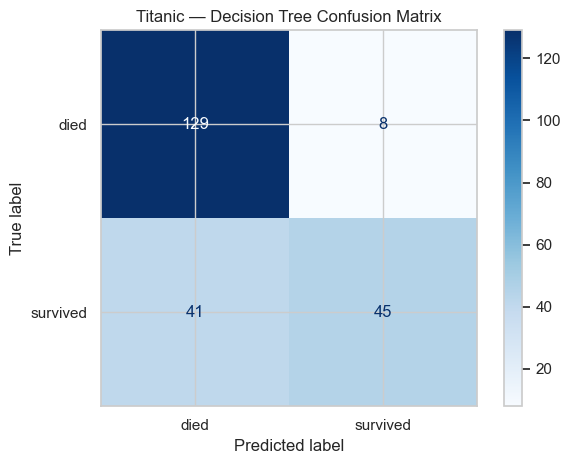

In [4]:
#Preprocess + Decision Tree pipeline
"""Numeric: median impute

Categorical: most‑frequent impute + one‑hot (handle_unknown='ignore')

Model: DecisionTreeClassifier(max_depth=4, random_state=0)
"""
num_feats = X.select_dtypes(include='number').columns.tolist()
cat_feats = X.select_dtypes(exclude='number').columns.tolist()

pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_feats),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_feats)
])

clf = Pipeline([
    ('prep', pre),
    ('tree', DecisionTreeClassifier(max_depth=4, random_state=0))
]).fit(X_train, y_train)

y_pred = clf.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=['died','survived']))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['died','survived']).plot(cmap='Blues')
plt.title('Titanic — Decision Tree Confusion Matrix'); plt.tight_layout(); plt.show()

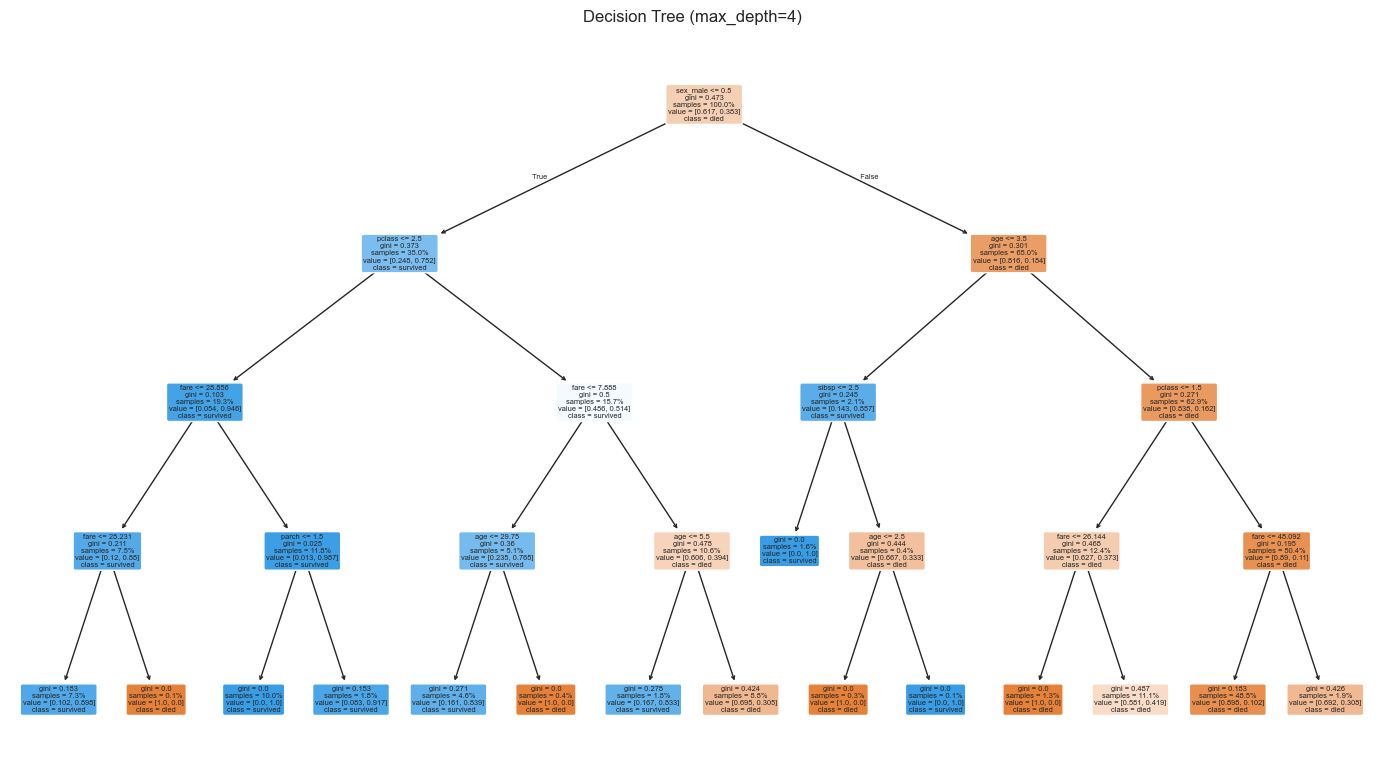

|--- sex_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 28.86
|   |   |   |--- fare <= 28.23
|   |   |   |   |--- class: 1
|   |   |   |--- fare >  28.23
|   |   |   |   |--- class: 0
|   |   |--- fare >  28.86
|   |   |   |--- parch <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- parch >  1.50
|   |   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 7.89
|   |   |   |--- age <= 29.75
|   |   |   |   |--- class: 1
|   |   |   |--- age >  29.75
|   |   |   |   |--- class: 0
|   |   |--- fare >  7.89
|   |   |   |--- age <= 5.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  5.50
|   |   |   |   |--- class: 0
|--- sex_male >  0.50
|   |--- age <= 3.50
|   |   |--- sibsp <= 2.50
|   |   |   |--- class: 1
|   |   |--- sibsp >  2.50
|   |   |   |--- age <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  2.50
|   |   |   |   |--- class: 1
|   |--- age >  3.50
|   |   |--- pclass <= 1.50
|   |   |   |--- fare <= 26.14
|   |   |   |   |--- 

In [5]:
#Visualize the tree (no Graphviz needed)
oh = clf.named_steps['prep'].named_transformers_['cat'].named_steps['oh']
feat_names = list(num_feats) + oh.get_feature_names_out(cat_feats).tolist()

plt.figure(figsize=(14,8))
plot_tree(clf.named_steps['tree'], feature_names=feat_names, class_names=['died','survived'],
          filled=True, impurity=True, rounded=True, proportion=True)
plt.title('Decision Tree (max_depth=4)'); plt.tight_layout(); plt.show()

# Compact text view
print(export_text(clf.named_steps['tree'], feature_names=feat_names, decimals=2))

In [6]:
#Trace a single passenger’s decision path
#Shows each node’s split, the example’s value, and the direction taken.
idx = X_test.index[0]      # pick a test passenger
x_row = X.loc[[idx]]
true_label = y.loc[idx]
pred_label = clf.predict(x_row)[0]
pred_proba = clf.predict_proba(x_row)[0, pred_label]

X_row_trans = clf.named_steps['prep'].transform(x_row)
tree_est = clf.named_steps['tree']
path = tree_est.decision_path(X_row_trans).tocoo()

print('Passenger index:', int(idx))
print('True:', int(true_label), '| Pred:', int(pred_label), f'(p={pred_proba:.2f})')

for node_id in path.col:
    if tree_est.tree_.feature[node_id] == -2:
        print(f'→ Leaf node {node_id} | n_samples={tree_est.tree_.n_node_samples[node_id]}')
        continue
    feat = feat_names[tree_est.tree_.feature[node_id]]
    thresh = tree_est.tree_.threshold[node_id]
    val = X_row_trans[0, tree_est.tree_.feature[node_id]]
    go_left = val <= thresh
    print(f'Node {node_id}: if {feat} ≤ {thresh:.3f}? value={val:.3f} → go {"left (≤)" if go_left else "right (>)"}')

Passenger index: 157
True: 0 | Pred: 0 (p=0.90)
Node 0: if sex_male ≤ 0.500? value=1.000 → go right (>)
Node 16: if age ≤ 3.500? value=30.000 → go right (>)
Node 22: if pclass ≤ 1.500? value=3.000 → go right (>)
Node 26: if fare ≤ 48.092? value=8.050 → go left (≤)
→ Leaf node 27 | n_samples=324


In [7]:
#Feature importance (top 12)
depths = [2,3,4,5,6,None]
scores = []
for d in depths:
    model = Pipeline([('prep', pre), ('tree', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    scores.append((str(d), model.score(X_test, y_test)))
scores

[('2', 0.757847533632287),
 ('3', 0.7847533632286996),
 ('4', 0.7802690582959642),
 ('5', 0.7713004484304933),
 ('6', 0.7757847533632287),
 ('None', 0.7309417040358744)]

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load sample data (replace this with your own data loading logic)
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Experiment with different max_depth values
depths = [3, 5, 6]

print(f"{'Max Depth':<12} {'Train Acc':<12} {'Test Acc':<12} {'Total Nodes':<12} {'Total Leaves':<12}")
print("-" * 65)

for depth in depths:
    # Initialize and train the model
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    # Get tree shape details
    n_nodes = clf.tree_.node_count
    n_leaves = clf.tree_.n_leaves
    
    print(f"{depth:<12} {train_acc:.4f}      {test_acc:.4f}      {n_nodes:<12} {n_leaves:<12}")

print("-" * 65)
print("Interpretation:")
print("Overfitting typically begins where Training Accuracy increases while Test Accuracy stays flat or decreases.")


Max Depth    Train Acc    Test Acc     Total Nodes  Total Leaves
-----------------------------------------------------------------
3            0.9780      0.9474      15           8           
5            0.9956      0.9474      25           13          
6            0.9978      0.9386      29           15          
-----------------------------------------------------------------
Interpretation:
Overfitting typically begins where Training Accuracy increases while Test Accuracy stays flat or decreases.


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Preprocessing
# Select features that are significant for prediction
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].copy()
y = df['Survived']

# Handle missing values: Fill missing Age with the median
X['Age'] = X['Age'].fillna(X['Age'].median())

# Handle categorical data: Map 'Sex' to binary values
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Experiment with max_depth = 3, 5, 6
depths = [3, 5, 6]

print(f"{'Max Depth':<12} {'Train Acc':<12} {'Test Acc':<12} {'Total Nodes':<12} {'Total Leaves':<12}")
print("-" * 65)

for depth in depths:
    # Initialize and train
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    # Get tree shape
    n_nodes = clf.tree_.node_count
    n_leaves = clf.tree_.n_leaves
    
    print(f"{depth:<12} {train_acc:.4f}      {test_acc:.4f}      {n_nodes:<12} {n_leaves:<12}")

print("-" * 65)


Max Depth    Train Acc    Test Acc     Total Nodes  Total Leaves
-----------------------------------------------------------------
3            0.8343      0.7989      15           8           
5            0.8581      0.8045      47           24          
6            0.8666      0.7821      71           36          
-----------------------------------------------------------------


Results with min_samples_leaf=10
Max Depth    Train Acc    Test Acc     Total Nodes  Total Leaves
-----------------------------------------------------------------
3            0.8272      0.7933      15           8           
5            0.8427      0.8045      37           19          
6            0.8455      0.7933      47           24          
-----------------------------------------------------------------


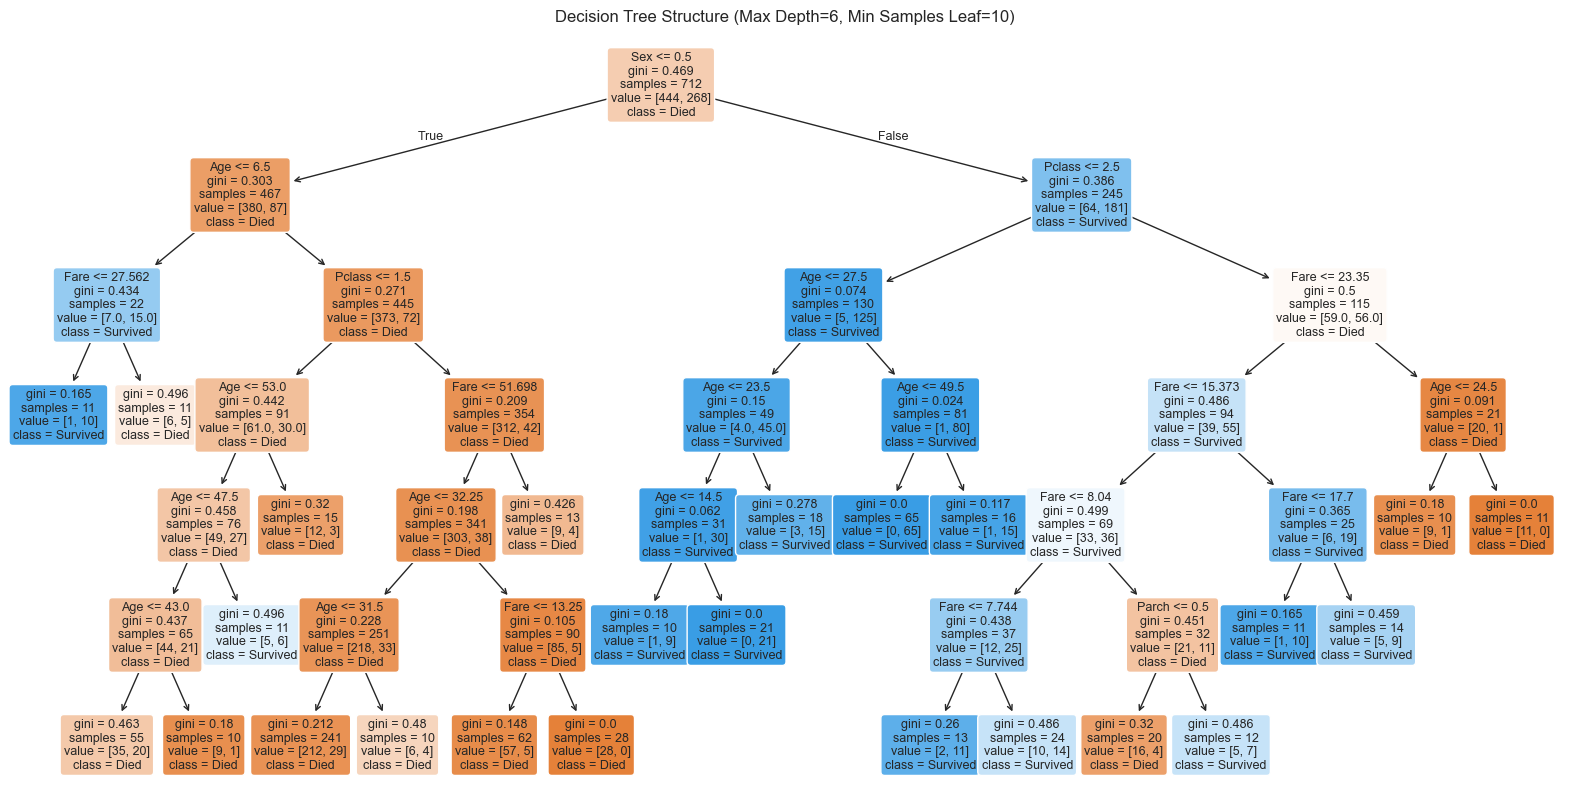

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 1. Load and Preprocess Titanic Data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].copy()
y = df['Survived']

# Fill missing Age and encode Sex
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Experiment with max_depth = 3, 5, 6 AND min_samples_leaf = 10
depths = [3, 5, 6]
min_samples = 10

print(f"Results with min_samples_leaf={min_samples}")
print(f"{'Max Depth':<12} {'Train Acc':<12} {'Test Acc':<12} {'Total Nodes':<12} {'Total Leaves':<12}")
print("-" * 65)

models = {}  # Store models to visualize later

for depth in depths:
    # Initialize with both max_depth and min_samples_leaf
    clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=min_samples, random_state=42)
    clf.fit(X_train, y_train)
    models[depth] = clf
    
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    n_nodes = clf.tree_.node_count
    n_leaves = clf.tree_.n_leaves
    
    print(f"{depth:<12} {train_acc:.4f}      {test_acc:.4f}      {n_nodes:<12} {n_leaves:<12}")

print("-" * 65)

# 3. Visualization: Plot the deepest tree (Depth 6) to see the pruning effect
plt.figure(figsize=(20, 10))
plot_tree(models[6], 
          feature_names=features, 
          class_names=['Died', 'Survived'], 
          filled=True, 
          rounded=True, 
          fontsize=9)
plt.title(f"Decision Tree Structure (Max Depth=6, Min Samples Leaf={min_samples})")
plt.show()


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Setup Data (Titanic)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].copy()
y = df['Survived']

# Preprocessing
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model (Depth 3 for readability)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 3. Helper Function to Explain Paths
def explain_decision_path(model, X_data, sample_index):
    # Get the specific sample (reshape to 2D array)
    sample = X_data.iloc[sample_index].values.reshape(1, -1)
    feature_names = X_data.columns
    
    # Get the path of nodes the sample traverses
    node_indicator = model.decision_path(sample)
    node_index = node_indicator.indices
    
    # Get tree details
    n_nodes = model.tree_.node_count
    children_left = model.tree_.children_left
    children_right = model.tree_.children_right
    feature = model.tree_.feature
    threshold = model.tree_.threshold
    
    print(f"\n--- Decision Path for Passenger Index {sample_index} ---")
    print(f"Actual Data: {X_data.iloc[sample_index].to_dict()}")
    
    # Traverse the path
    for node_id in node_index:
        # If leaf node
        if children_left[node_id] == children_right[node_id]:
            prediction_class = model.classes_[np.argmax(model.tree_.value[node_id])]
            pred_label = "Survived" if prediction_class == 1 else "Died"
            print(f"  -> LEAF NODE {node_id}: Final Prediction = {pred_label}")
        else:
            # If decision node
            feat_name = feature_names[feature[node_id]]
            feat_val = sample[0][feature[node_id]]
            thresh = threshold[node_id]
            
            # Determine logic
            if feat_val <= thresh:
                decision = f"{feat_val:.2f} <= {thresh:.2f} (True)"
                direction = "Left"
            else:
                decision = f"{feat_val:.2f} > {thresh:.2f} (False)"
                direction = "Right"
                
            print(f"  NODE {node_id}: Is {feat_name} <= {thresh:.2f}? | Value: {feat_val} | Decision: {decision} -> Go {direction}")

# 4. Pick 3 Passengers and Explain
# We pick indices 0, 5, and 20 from the test set as examples
pick_indices = [0, 5, 20]

for i in pick_indices:
    explain_decision_path(clf, X_test, i)



--- Decision Path for Passenger Index 0 ---
Actual Data: {'Pclass': 3.0, 'Sex': 0.0, 'Age': 28.0, 'SibSp': 1.0, 'Parch': 1.0, 'Fare': 15.2458}
  NODE 0: Is Sex <= 0.50? | Value: 0.0 | Decision: 0.00 <= 0.50 (True) -> Go Left
  NODE 1: Is Age <= 6.50? | Value: 28.0 | Decision: 28.00 > 6.50 (False) -> Go Right
  NODE 5: Is Pclass <= 1.50? | Value: 3.0 | Decision: 3.00 > 1.50 (False) -> Go Right
  -> LEAF NODE 7: Final Prediction = Died

--- Decision Path for Passenger Index 5 ---
Actual Data: {'Pclass': 1.0, 'Sex': 1.0, 'Age': 26.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 78.85}
  NODE 0: Is Sex <= 0.50? | Value: 1.0 | Decision: 1.00 > 0.50 (False) -> Go Right
  NODE 8: Is Pclass <= 2.50? | Value: 1.0 | Decision: 1.00 <= 2.50 (True) -> Go Left
  NODE 9: Is Age <= 2.50? | Value: 26.0 | Decision: 26.00 > 2.50 (False) -> Go Right
  -> LEAF NODE 11: Final Prediction = Survived

--- Decision Path for Passenger Index 20 ---
Actual Data: {'Pclass': 3.0, 'Sex': 0.0, 'Age': 24.0, 'SibSp': 0.0, 'Parc

C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Explanation of the Output Logic
When you run this code, it breaks down the "Black Box" of the decision tree:

decision_path: This sklearn method returns a sparse matrix indicating every node ID a sample passes through.
Node Traversal: The loop iterates through these IDs.
Comparison: At every step, it checks the passenger's actual value (e.g., Sex=0) against the learned threshold (e.g., 0.50).
If the condition is True (Value <= Threshold), the path goes Left.
If the condition is False (Value > Threshold), the path goes Right.
Leaf Node: When the loop reaches a node with no children, it prints the final class prediction (Survived or Died).

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load and Preprocess Titanic Data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].copy()
y = df['Survived']

# Fill missing Age and encode Sex
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Random Forest Classifier
# n_estimators=200 creates 200 individual decision trees
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)

# 3. Calculate Accuracy
train_acc = accuracy_score(y_train, rf_clf.predict(X_train))
test_acc = accuracy_score(y_test, rf_clf.predict(X_test))

print(f"{'Model':<20} {'Train Acc':<12} {'Test Acc':<12}")
print("-" * 45)
print(f"{'Random Forest (n=200)':<20} {train_acc:.4f}      {test_acc:.4f}")
print("-" * 45)

# 4. Extract and Compare Feature Importances
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1] # Sort indices descending

print("\nFeature Importances:")
print(f"{'Rank':<6} {'Feature':<12} {'Importance':<12}")
print("-" * 35)

for f in range(X_train.shape[1]):
    rank = f + 1
    feature_name = features[indices[f]]
    importance_val = importances[indices[f]]
    print(f"{rank:<6} {feature_name:<12} {importance_val:.4f}")

print("-" * 35)
print("Interpretation:")
print("1. Accuracy: Random Forest usually has higher Test Accuracy than a single tree because it averages out errors (reduces variance).")
print("2. Importances: Unlike a single tree which might over-emphasize the root split, Random Forest aggregates importance across 200 trees, providing a more robust view of which features matter most (often Sex, Fare, or Age).")


Model                Train Acc    Test Acc    
---------------------------------------------
Random Forest (n=200) 0.9789      0.7989
---------------------------------------------

Feature Importances:
Rank   Feature      Importance  
-----------------------------------
1      Fare         0.3020
2      Sex          0.2722
3      Age          0.2563
4      Pclass       0.0827
5      SibSp        0.0502
6      Parch        0.0366
-----------------------------------
Interpretation:
1. Accuracy: Random Forest usually has higher Test Accuracy than a single tree because it averages out errors (reduces variance).
2. Importances: Unlike a single tree which might over-emphasize the root split, Random Forest aggregates importance across 200 trees, providing a more robust view of which features matter most (often Sex, Fare, or Age).
